Last edited: 1/28/2026, 3:38 PM CST
# Bias vs. Variance Explained Analysis for Nonstationary GEV Fits to CMIP6 Models
## All mems + primary mems

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import linregress

from config import DATA_ROOT
from src.utils import extract_model_name
from src.cmip_dataclass import CMIP6EnsembleConfig
from src.plotting_presets import get_presets

# import custom stuff
from ambpy.plotutils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [2]:
# Set color and marker sets for CMIP models
# 10 High-Contrast, Colorblind-Friendly Hex Codes (Paul Tol / Okabe-Ito)
colors = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', 
          '#AA3377', '#EE7733', '#009988', '#332288', '#BBBBBB']

# Marker Set
markers = ['o', 's', 'D'] # Circle, Square, Diamond

## Step 0: Set Data Attributes for Analysis

In [29]:
# shared attributes
fit = 'nonstat'
anom_type = "raw"

# set anomaly type
if anom_type == 'raw':
    data_type = 'raw'
else:
    data_type = f"anom_{anom_type}"

In [30]:
# attributes of ERA5 data
TMIN = 1979
era5_variable = 't2m_annual_min'

In [31]:
# attributes of CMIP data
cmip_variable = 'tas_annual_min'
CMIPConfig = CMIP6EnsembleConfig.from_yaml(
    'config/meta.yaml',
    'config/qc.yaml'
)

# make file/model matcher for 
data_path = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev'

# Make all landonly file names
fnames = [f for f in data_path.glob(f"*{fit}*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

modelname_filepath_matcher = {
extract_model_name(f): f for f in fnames
}

## Step 1: Import ERA5 Data and Initialize Quantities of Interest for CMIP Comparison

In [32]:
# import relevant ERA5 file
ds_era5 = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_{era5_variable}_1deg_landonly_gev_{fit}_TMIN{TMIN}.nc', engine='netcdf4')
PER_DECADE_CONVERSTION_FACTOR = 10 / len(ds_era5.year.values)

# store flattened, screened numpy arrays of ERA5 fit variables for regressions and bias calculations later
if fit == 'nonstat':
    era5_loc, era5_loc_trend = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_scale, era5_scale_trend = ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_shape, era5_shape_trend = ds_era5[f'shape_{data_type}'].values.flatten(), ds_era5[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

elif fit == 'stat':
    era5_loc, era5_scale, era5_shape = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'shape_{data_type}'].values.flatten()

else:
    raise ValueError("Invalid `fit` variable.")


Setup for primary model member analysis.

In [33]:
# get number of models for this variable
N_active_models = len(
    list(m for m in CMIPConfig.iter_active_models(cmip_variable))
)

if fit == 'nonstat':
    # median absolute deviation
    med_abs_dev_prim = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

    mean_abs_dev_prim = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

    r2s_prim = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

elif fit == 'stat':
    med_abs_dev_prim = {
        'loc': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
    }

else:
    raise ValueError("Invalid `fit`.")

Setup for analyzing the model with the most ensemble members (probably MIROC6 but there can be others).

In [34]:
# Calculate number of ensemble members for each active model
Nens_for_active_models = np.array([
    len(m.all_members) for m in CMIPConfig.iter_active_models(cmip_variable)
])

# Find model(s) with most members
max_inds = np.where(Nens_for_active_models == np.max(Nens_for_active_models))[0]

# Select first model with most members
ind_ = max_inds[0]
model_with_most = [m.name for m in CMIPConfig.iter_active_models(cmip_variable)][ind_]
N_members = np.max(Nens_for_active_models)

if fit == 'nonstat':
    # median absolute deviation
    med_abs_dev_most = {
        'loc': np.zeros(N_members),
        'loc_trend': np.zeros(N_members),
        'scale': np.zeros(N_members),
        'scale_trend': np.zeros(N_members),
        'shape': np.zeros(N_members),
        'shape_trend': np.zeros(N_members)
    }

    mean_abs_dev_most = {
        'loc': np.zeros(N_members),
        'loc_trend': np.zeros(N_members),
        'scale': np.zeros(N_members),
        'scale_trend': np.zeros(N_members),
        'shape': np.zeros(N_members),
        'shape_trend': np.zeros(N_members)
    }

    r2s_most = {
        'loc': np.zeros(N_members),
        'loc_trend': np.zeros(N_members),
        'scale': np.zeros(N_members),
        'scale_trend': np.zeros(N_members),
        'shape': np.zeros(N_members),
        'shape_trend': np.zeros(N_members)
    }

elif fit == 'stat':
    med_abs_dev_most = {
        'loc': np.zeros(N_members),
        'scale': np.zeros(N_members),
        'shape': np.zeros(N_members),
    }

else:
    raise ValueError("Invalid `fit`.")

print(f"We will analyze {model_with_most}, which has {N_members} ensemble members.")

We will analyze MIROC6, which has 50 ensemble members.


In [35]:
def mutual_mask_perc(x, y, p_lo, p_hi):
    xnew = x[
        (x >= np.nanpercentile(x, p_lo)) & (x <= np.nanpercentile(x, p_hi))
    ]
    ynew = y[
        (x >= np.nanpercentile(x, p_lo)) & (x <= np.nanpercentile(x, p_hi))
    ]

    yfinal = ynew[
        (ynew >= np.nanpercentile(y, p_lo)) & (ynew <= np.nanpercentile(y, p_hi))
    ]

    xfinal = xnew[
        (ynew >= np.nanpercentile(y, p_lo)) & (ynew <= np.nanpercentile(y, p_hi))
    ]

    return xfinal, yfinal

In [36]:
def plot_scatter_regression(x_data, y_data, slopes, intercepts, r2s, model_name):
    fig, ax = plt.subplots(3, 2, figsize=(12, 16))
    titles = [r'Location Parameter', r'Location Parameter Trend',
            r'Scale Parameter', r'Scale Parameter Trend',
            r'Shape Parameter', r'Shape Parameter Trend']

    x_labels = [r'$\bar{\mu}_{ERA5}$ ($^\circ$C)', r"$\mu_{ERA5}'$ ($^\circ$C/decade)",
                r'$\bar{\sigma}_{ERA5}$ ($^\circ$C)', r"$\sigma_{ERA5}'$ ($^\circ$C/decade)",
                r'$\bar{\xi}_{ERA5}$ ($-$)', r"$\xi_{ERA5}'$ (decade$^{-1}$)"]

    y_labels = [r'$\bar{\mu}_{CMIP}$ ($^\circ$C)', r"$\mu_{CMIP}'$ ($^\circ$C/decade)",
                r'$\bar{\sigma}_{CMIP}$ ($^\circ$C)', r"$\sigma_{CMIP}'$ ($^\circ$C/decade)",
                r'$\bar{\xi}_{CMIP}$ ($-$)', r"$\xi_{CMIP}'$ (decade$^{-1}$)"]
    
    for (a, x, y, slope, intercept, r2, x_label, y_label, title) in zip(ax.flatten(), x_data, y_data, slopes, intercepts, r2s, x_labels, y_labels, titles):
        # data and regression lines
        a.scatter(x, y, s=1, marker='.', c='grey')  # data
        a.plot(np.arange(min(x), max(x), (max(x) - min(x))/1000),
                np.arange(min(x), max(x), (max(x) - min(x))/1000),
                linewidth=2.5, linestyle='dashed', color='r')  # one to one line
        a.plot(x, slope * x + intercept, linestyle='solid', color='b', linewidth=2.5, label=f"r$^2$={r2:.2f}")  # regression line

        # aesthetics
        a.set_title(title)
        a.set_xlabel(x_label)
        a.set_ylabel(y_label)
        a.legend()
    
    fig.suptitle(f"Model: {model_name}")
    fig.tight_layout()

    fname = make_figure_filename(f'era5_{model_name}_nonstat_gev_comparison_{cmip_variable}_{anom_type}', 'png', 'figs/checks')
    fig.savefig(fname, dpi=300)
    print(f"     Figure saved to: {fname}")

## Step 2: Loop Through CMIP Model with Most Members and Carry Out Fitting

In [37]:
# Find all 'allmems' GEV files for the chosen model and anomaly type
gev_dir = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev'
pattern = f"*{model_with_most}*{fit}*allmems*{anom_type}.nc"
allmems_files = sorted(gev_dir.glob(pattern))
print(f"Found {len(allmems_files)} files matching: {pattern}")
for p in allmems_files:
    print(p.name)

# expose the list for later use
allmems_filepaths = allmems_files

Found 1 files matching: *MIROC6*nonstat*allmems*raw.nc
tas_CMIP6_MIROC6_hist+ssp585_1979-2024_landonly_gev_nonstat_allmems_raw.nc


Loop through "most member" model.

In [38]:
# percentiles for masking
plo = 5
phi = 95

MAKE_CHECKS = False

ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

for idx, mem in enumerate(ds.member_id.values):
    print(f"\n⚒️ Working on member: {mem}")

    tmp_ds = ds.sel(member_id=mem)

    # carry out calculations for both nonstationary and stationary cases
    if fit == 'nonstat':
        # extract model variables
        m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

        # mutually mask era5 and model parameters
        era5_loc_masked, m_loc_masked = mutual_mask_perc(era5_loc, m_loc, plo, phi)
        era5_loc_trend_masked, m_loc_trend_masked = mutual_mask_perc(era5_loc_trend, m_loc_trend, plo, phi)

        era5_scale_masked, m_scale_masked = mutual_mask_perc(era5_scale, m_scale, plo, phi)
        era5_scale_trend_masked, m_scale_trend_masked = mutual_mask_perc(era5_scale_trend, m_scale_trend, plo, phi)

        era5_shape_masked, m_shape_masked = mutual_mask_perc(era5_shape, m_shape, plo, phi)
        era5_shape_trend_masked, m_shape_trend_masked = mutual_mask_perc(era5_shape_trend, m_shape_trend, plo, phi)

        # compute absolute deviations of parameters between model and era
        tmp_abs_dev_loc = m_loc_masked - era5_loc_masked
        tmp_abs_dev_loc_trend = m_loc_trend_masked - era5_loc_trend_masked

        tmp_abs_dev_scale = m_scale_masked - era5_scale_masked
        tmp_abs_dev_scale_trend = m_scale_trend_masked - era5_scale_trend_masked

        tmp_abs_dev_shape = m_shape_masked - era5_shape_masked
        tmp_abs_dev_shape_trend = m_shape_trend_masked - era5_shape_trend_masked

        # store nanmedians and nanmeans
        ## nanmedian
        med_abs_dev_most['loc'][idx] = np.nanmedian(tmp_abs_dev_loc)
        med_abs_dev_most['loc_trend'][idx] = np.nanmedian(tmp_abs_dev_loc_trend)

        med_abs_dev_most['scale'][idx] = np.nanmedian(tmp_abs_dev_scale)
        med_abs_dev_most['scale_trend'][idx] = np.nanmedian(tmp_abs_dev_scale_trend)

        med_abs_dev_most['shape'][idx] = np.nanmedian(tmp_abs_dev_shape)
        med_abs_dev_most['shape_trend'][idx] = np.nanmedian(tmp_abs_dev_shape_trend)

        ## nanmean
        mean_abs_dev_most['loc'][idx] = np.nanmean(tmp_abs_dev_loc)
        mean_abs_dev_most['loc_trend'][idx] = np.nanmean(tmp_abs_dev_loc_trend)

        mean_abs_dev_most['scale'][idx] = np.nanmean(tmp_abs_dev_scale)
        mean_abs_dev_most['scale_trend'][idx] = np.nanmean(tmp_abs_dev_scale_trend)

        mean_abs_dev_most['shape'][idx] = np.nanmean(tmp_abs_dev_shape)
        mean_abs_dev_most['shape_trend'][idx] = np.nanmean(tmp_abs_dev_shape_trend)

        # regress against ERA5 equivalents
        # NOTE: nan_policy='omit' because nans are ocean values
        loc_reg = linregress(era5_loc_masked, m_loc_masked)
        loc_slope, loc_inter, loc_r2 = loc_reg.slope, loc_reg.intercept, loc_reg.rvalue**2
        r2s_most['loc'][idx] = loc_r2

        loc_trend_reg = linregress(era5_loc_trend_masked, m_loc_trend_masked)
        loct_slope, loct_inter, loct_r2 = loc_trend_reg.slope, loc_trend_reg.intercept, loc_trend_reg.rvalue**2
        r2s_most['loc_trend'][idx] = loct_r2

        scale_reg = linregress(era5_scale_masked, m_scale_masked)
        scale_slope, scale_inter, scale_r2 = scale_reg.slope, scale_reg.intercept, scale_reg.rvalue**2
        r2s_most['scale'][idx] = scale_r2

        scale_trend_reg = linregress(era5_scale_trend_masked, m_scale_trend_masked)
        scalet_slope, scalet_inter, scalet_r2 = scale_trend_reg.slope, scale_trend_reg.intercept, scale_trend_reg.rvalue**2
        r2s_most['scale_trend'][idx] = scalet_r2

        shape_reg = linregress(era5_shape_masked, m_shape_masked)
        shape_slope, shape_inter, shape_r2 = shape_reg.slope, shape_reg.intercept, shape_reg.rvalue**2
        r2s_most['shape'][idx] = shape_r2

        shape_trend_reg = linregress(era5_shape_trend_masked, m_shape_trend_masked)
        shapet_slope, shapet_inter, shapet_r2 = shape_trend_reg.slope, shape_trend_reg.intercept, shape_trend_reg.rvalue**2
        r2s_most['shape_trend'][idx] = shapet_r2

        if MAKE_CHECKS:
            # make check plot
            plot_scatter_regression(
                x_data=[era5_loc_masked, era5_loc_trend_masked, era5_scale_masked, era5_scale_trend_masked, era5_shape_masked, era5_shape_trend_masked],
                y_data=[m_loc_masked, m_loc_trend_masked, m_scale_masked, m_scale_trend_masked, m_shape_masked, m_shape_trend_masked],
                slopes=[loc_slope, loct_slope, scale_slope, scalet_slope, shape_slope, shapet_slope],
                intercepts=[loc_inter, loct_inter, scale_inter, scalet_inter, shape_inter, shapet_inter],
                r2s=[loc_r2, loct_r2, scale_r2, scalet_r2, shape_r2, shapet_r2],
                model_name=f"{model_with_most}_{mem}"
            )

        plt.close()

    else:
        import warnings
        warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

    tmp_ds.close()



⚒️ Working on member: MIROC6_r49i1p1f1

⚒️ Working on member: MIROC6_r4i1p1f1

⚒️ Working on member: MIROC6_r50i1p1f1

⚒️ Working on member: MIROC6_r5i1p1f1

⚒️ Working on member: MIROC6_r6i1p1f1

⚒️ Working on member: MIROC6_r7i1p1f1

⚒️ Working on member: MIROC6_r10i1p1f1

⚒️ Working on member: MIROC6_r8i1p1f1

⚒️ Working on member: MIROC6_r11i1p1f1

⚒️ Working on member: MIROC6_r9i1p1f1

⚒️ Working on member: MIROC6_r12i1p1f1

⚒️ Working on member: MIROC6_r13i1p1f1

⚒️ Working on member: MIROC6_r14i1p1f1

⚒️ Working on member: MIROC6_r15i1p1f1

⚒️ Working on member: MIROC6_r16i1p1f1

⚒️ Working on member: MIROC6_r17i1p1f1

⚒️ Working on member: MIROC6_r18i1p1f1

⚒️ Working on member: MIROC6_r19i1p1f1

⚒️ Working on member: MIROC6_r1i1p1f1

⚒️ Working on member: MIROC6_r20i1p1f1

⚒️ Working on member: MIROC6_r21i1p1f1

⚒️ Working on member: MIROC6_r22i1p1f1

⚒️ Working on member: MIROC6_r23i1p1f1

⚒️ Working on member: MIROC6_r24i1p1f1

⚒️ Working on member: MIROC6_r25i1p1f1

⚒️ Wor

In [39]:
# percentiles for masking
plo = 5
phi = 95

# loop through models 
for (i, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
    print(f"\n⚒️ Working on {m.name}...")
    tmp_ds = xr.open_dataset(
        modelname_filepath_matcher[m.name]
    )

    # carry out calculations for both nonstationary and stationary cases
    if fit == 'nonstat':
        # extract model variables
        m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

        # mutually mask era5 and model parameters
        era5_loc_masked, m_loc_masked = mutual_mask_perc(era5_loc, m_loc, plo, phi)
        era5_loc_trend_masked, m_loc_trend_masked = mutual_mask_perc(era5_loc_trend, m_loc_trend, plo, phi)

        era5_scale_masked, m_scale_masked = mutual_mask_perc(era5_scale, m_scale, plo, phi)
        era5_scale_trend_masked, m_scale_trend_masked = mutual_mask_perc(era5_scale_trend, m_scale_trend, plo, phi)

        era5_shape_masked, m_shape_masked = mutual_mask_perc(era5_shape, m_shape, plo, phi)
        era5_shape_trend_masked, m_shape_trend_masked = mutual_mask_perc(era5_shape_trend, m_shape_trend, plo, phi)

        # compute absolute deviations of parameters between model and era
        tmp_abs_dev_loc = m_loc_masked - era5_loc_masked
        tmp_abs_dev_loc_trend = m_loc_trend_masked - era5_loc_trend_masked

        tmp_abs_dev_scale = m_scale_masked - era5_scale_masked
        tmp_abs_dev_scale_trend = m_scale_trend_masked - era5_scale_trend_masked

        tmp_abs_dev_shape = m_shape_masked - era5_shape_masked
        tmp_abs_dev_shape_trend = m_shape_trend_masked - era5_shape_trend_masked

        # store nanmedians and nanmeans
        ## nanmedian
        med_abs_dev_prim['loc'][i] = np.nanmedian(tmp_abs_dev_loc)
        med_abs_dev_prim['loc_trend'][i] = np.nanmedian(tmp_abs_dev_loc_trend)

        med_abs_dev_prim['scale'][i] = np.nanmedian(tmp_abs_dev_scale)
        med_abs_dev_prim['scale_trend'][i] = np.nanmedian(tmp_abs_dev_scale_trend)

        med_abs_dev_prim['shape'][i] = np.nanmedian(tmp_abs_dev_shape)
        med_abs_dev_prim['shape_trend'][i] = np.nanmedian(tmp_abs_dev_shape_trend)

        ## nanmean
        mean_abs_dev_prim['loc'][i] = np.nanmean(tmp_abs_dev_loc)
        mean_abs_dev_prim['loc_trend'][i] = np.nanmean(tmp_abs_dev_loc_trend)

        mean_abs_dev_prim['scale'][i] = np.nanmean(tmp_abs_dev_scale)
        mean_abs_dev_prim['scale_trend'][i] = np.nanmean(tmp_abs_dev_scale_trend)

        mean_abs_dev_prim['shape'][i] = np.nanmean(tmp_abs_dev_shape)
        mean_abs_dev_prim['shape_trend'][i] = np.nanmean(tmp_abs_dev_shape_trend)

        # regress against ERA5 equivalents
        # NOTE: nan_policy='omit' because nans are ocean values
        loc_reg = linregress(era5_loc_masked, m_loc_masked)
        loc_slope, loc_inter, loc_r2 = loc_reg.slope, loc_reg.intercept, loc_reg.rvalue**2
        r2s_prim['loc'][i] = loc_r2

        loc_trend_reg = linregress(era5_loc_trend_masked, m_loc_trend_masked)
        loct_slope, loct_inter, loct_r2 = loc_trend_reg.slope, loc_trend_reg.intercept, loc_trend_reg.rvalue**2
        r2s_prim['loc_trend'][i] = loct_r2

        scale_reg = linregress(era5_scale_masked, m_scale_masked)
        scale_slope, scale_inter, scale_r2 = scale_reg.slope, scale_reg.intercept, scale_reg.rvalue**2
        r2s_prim['scale'][i] = scale_r2

        scale_trend_reg = linregress(era5_scale_trend_masked, m_scale_trend_masked)
        scalet_slope, scalet_inter, scalet_r2 = scale_trend_reg.slope, scale_trend_reg.intercept, scale_trend_reg.rvalue**2
        r2s_prim['scale_trend'][i] = scalet_r2

        shape_reg = linregress(era5_shape_masked, m_shape_masked)
        shape_slope, shape_inter, shape_r2 = shape_reg.slope, shape_reg.intercept, shape_reg.rvalue**2
        r2s_prim['shape'][i] = shape_r2

        shape_trend_reg = linregress(era5_shape_trend_masked, m_shape_trend_masked)
        shapet_slope, shapet_inter, shapet_r2 = shape_trend_reg.slope, shape_trend_reg.intercept, shape_trend_reg.rvalue**2
        r2s_prim['shape_trend'][i] = shapet_r2

        if MAKE_CHECKS:
            # make check plot
            plot_scatter_regression(
                x_data=[era5_loc_masked, era5_loc_trend_masked, era5_scale_masked, era5_scale_trend_masked, era5_shape_masked, era5_shape_trend_masked],
                y_data=[m_loc_masked, m_loc_trend_masked, m_scale_masked, m_scale_trend_masked, m_shape_masked, m_shape_trend_masked],
                slopes=[loc_slope, loct_slope, scale_slope, scalet_slope, shape_slope, shapet_slope],
                intercepts=[loc_inter, loct_inter, scale_inter, scalet_inter, shape_inter, shapet_inter],
                r2s=[loc_r2, loct_r2, scale_r2, scalet_r2, shape_r2, shapet_r2],
                model_name=m.name
            )

        plt.close()

    else:
        import warnings
        warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

    tmp_ds.close()



⚒️ Working on AWI-CM-1-1-MR...

⚒️ Working on BCC-CSM2-MR...

⚒️ Working on CAMS-CSM1-0...

⚒️ Working on CESM2-WACCM...

⚒️ Working on CMCC-CM2-SR5...

⚒️ Working on CMCC-ESM2...

⚒️ Working on CNRM-CM6-1-HR...

⚒️ Working on CNRM-ESM2-1...

⚒️ Working on EC-Earth3-CC...

⚒️ Working on EC-Earth3-Veg...

⚒️ Working on EC-Earth3-Veg-LR...

⚒️ Working on FGOALS-g3...

⚒️ Working on GFDL-CM4...

⚒️ Working on GFDL-ESM4...

⚒️ Working on HadGEM3-GC31-LL...

⚒️ Working on HadGEM3-GC31-MM...

⚒️ Working on IITM-ESM...

⚒️ Working on INM-CM4-8...

⚒️ Working on INM-CM5-0...

⚒️ Working on KACE-1-0-G...

⚒️ Working on KIOST-ESM...

⚒️ Working on MIROC-ES2L...

⚒️ Working on MIROC6...

⚒️ Working on MPI-ESM1-2-HR...

⚒️ Working on MPI-ESM1-2-LR...

⚒️ Working on NorCPM1...

⚒️ Working on NorESM2-LM...

⚒️ Working on TaiESM1...

⚒️ Working on UKESM1-0-LL...


✍️ Figure saved to: figs/analysis/2026-04-03-all_cmip_era5_r2_avgbias_tas_annual_min_raw_nonstat.png


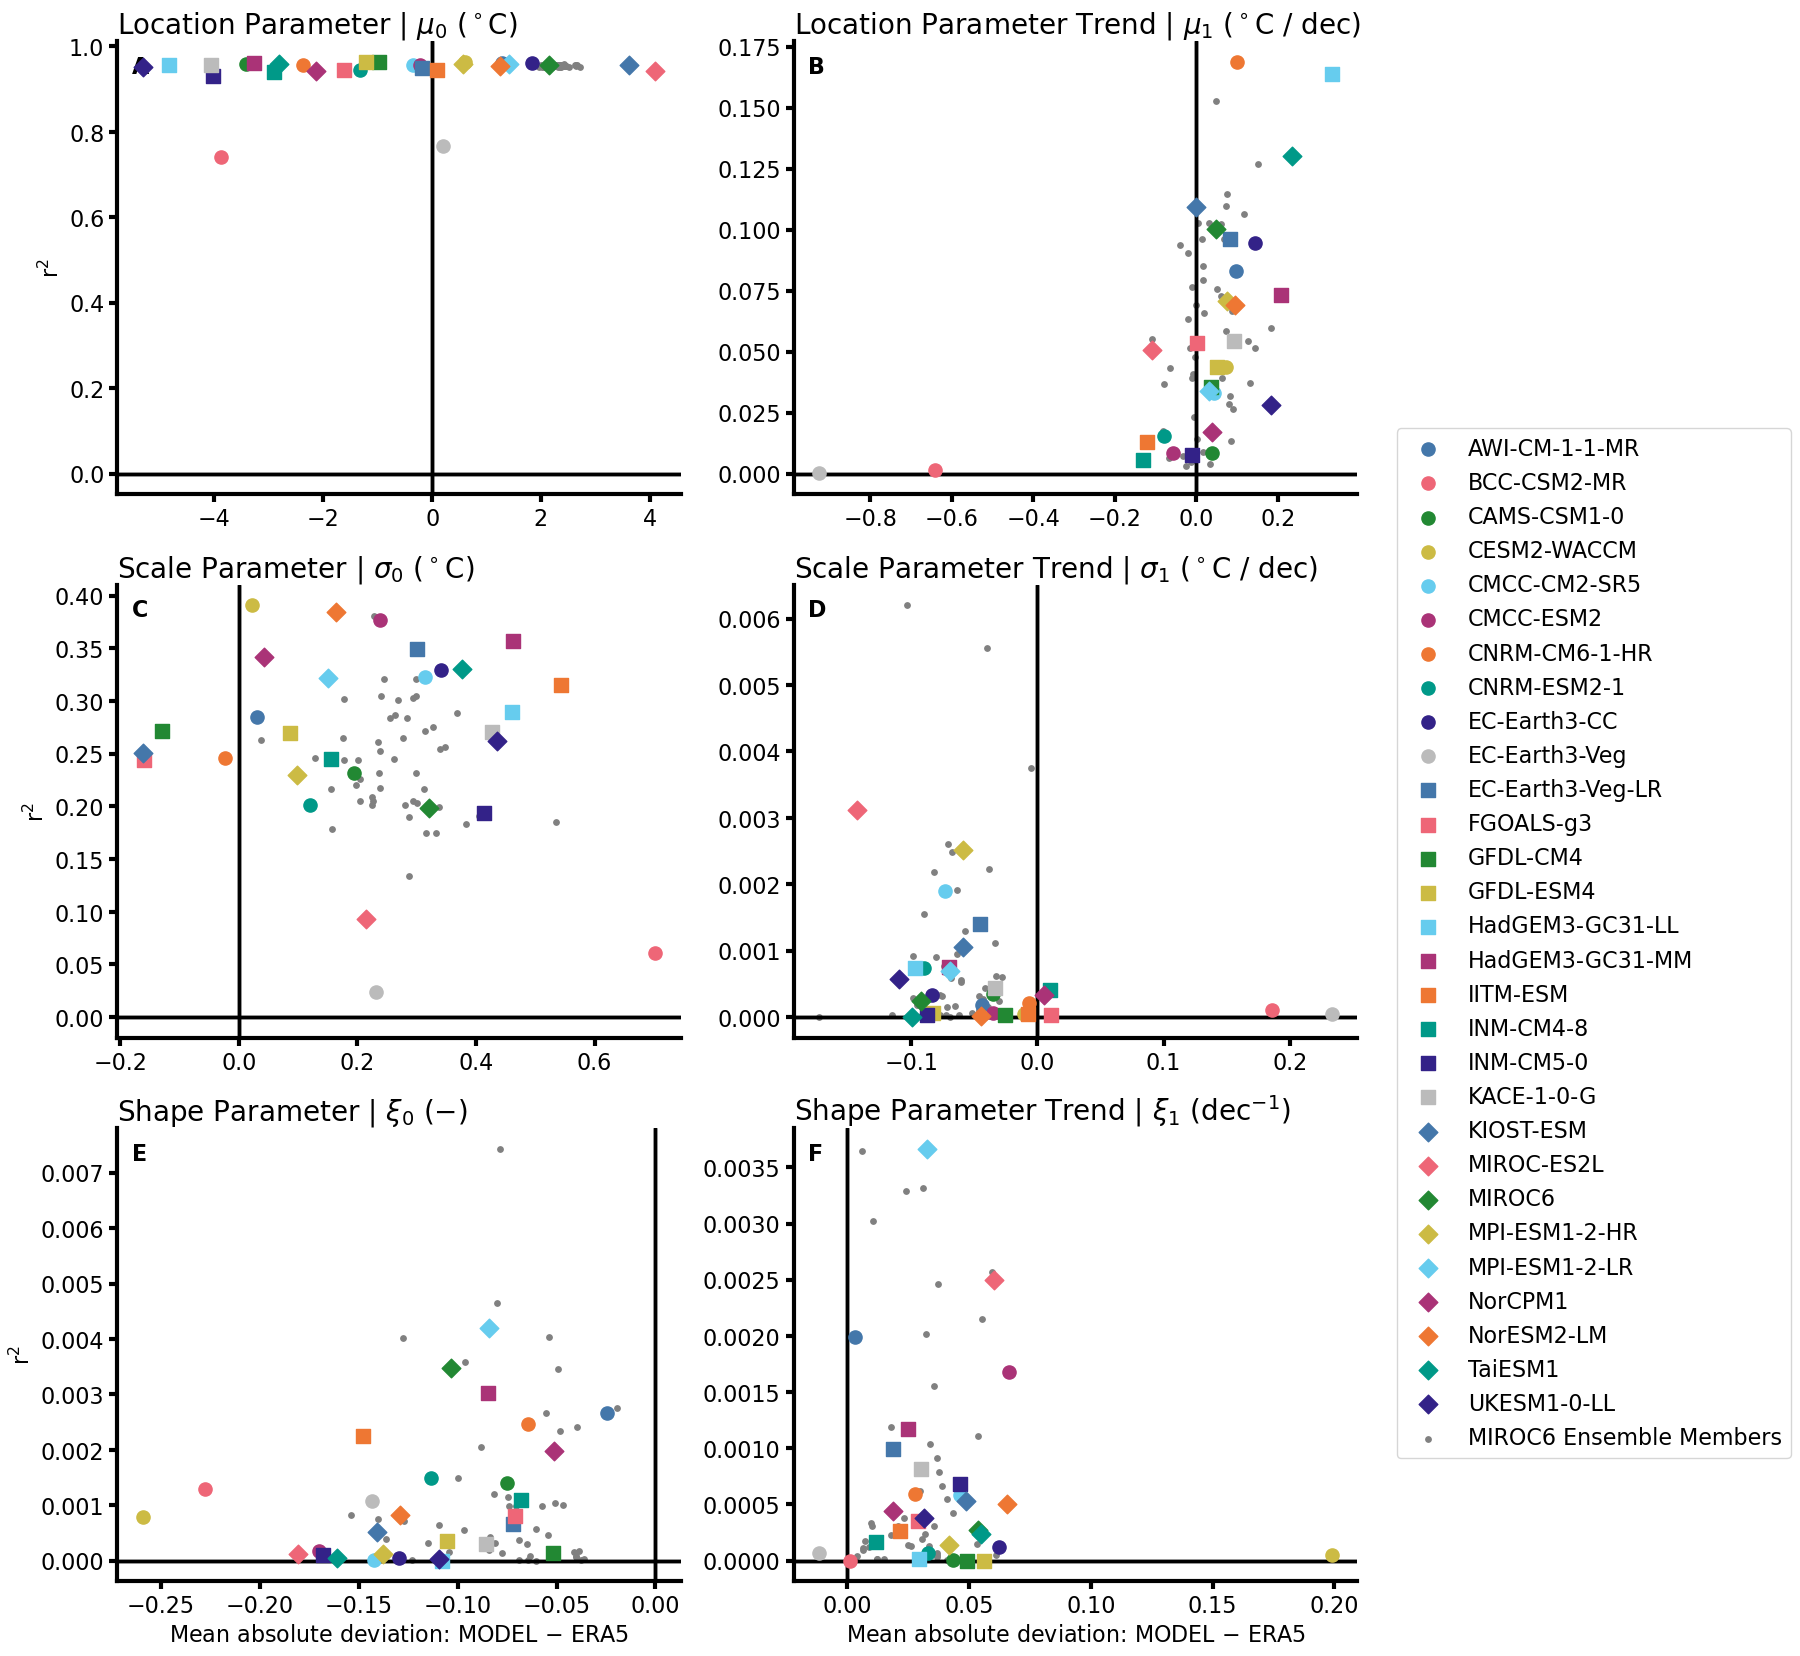

In [40]:
fig, ax = plt.subplots(3, 2, figsize=(16, 20))
titles = [r'Location Parameter | $\mu_0$ $(^\circ$C$)$', r"Location Parameter Trend | $\mu_1$ $(^\circ$C / dec$)$",
        r'Scale Parameter | $\sigma_0$ $(^\circ$C$)$', r"Scale Parameter Trend | $\sigma_1$ $(^\circ$C / dec$)$",
        r'Shape Parameter | $\xi_0$ $(-)$', r"Shape Parameter Trend | $\xi_1$ $($dec$^{-1})$"]
models = list(CMIPConfig.iter_active_models(cmip_variable))

have_ylabels = [0, 2, 4]
have_xlabels = [4, 5]

for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s_prim.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in enumerate(models):
        if m.name == model_with_most:
            most_color = colors[mdx % 10]

        marker = markers[mdx // 10]  # choose marker
        color = colors[mdx % 10]  # choose color

        a.scatter(mean_abs_dev_prim[var][mdx], r2s_prim[var][mdx], s=90, marker=marker, color=color, label=m.name, zorder=100)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("$r^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Mean absolute deviation: MODEL $-$ ERA5")


for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s_most.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in zip(range(N_members), ds.member_id.values):
        a.scatter(mean_abs_dev_most[var][mdx], r2s_most[var][mdx], s=60, marker='.', color='grey', zorder=1,
                  label=f'{model_with_most} Ensemble Members' if mdx == 0 else None)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("r$^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Mean absolute deviation: MODEL $-$ ERA5")

ax[1,1].legend(bbox_to_anchor=(1.05, 1.37), frameon=True)

labels = ['A', 'B', 'C', 'D', 'E', 'F']
for a, label in zip(ax.flatten(), labels):
    a.text(0.025, 0.97, label, transform=a.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

if save_figs:
    fname = make_figure_filename(f'all_cmip_era5_r2_avgbias_{cmip_variable}_{anom_type}_{fit}', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

✍️ Figure saved to: figs/analysis/2026-04-03-all_cmip_era5_r2_medbias_tas_annual_min_raw_nonstat.png


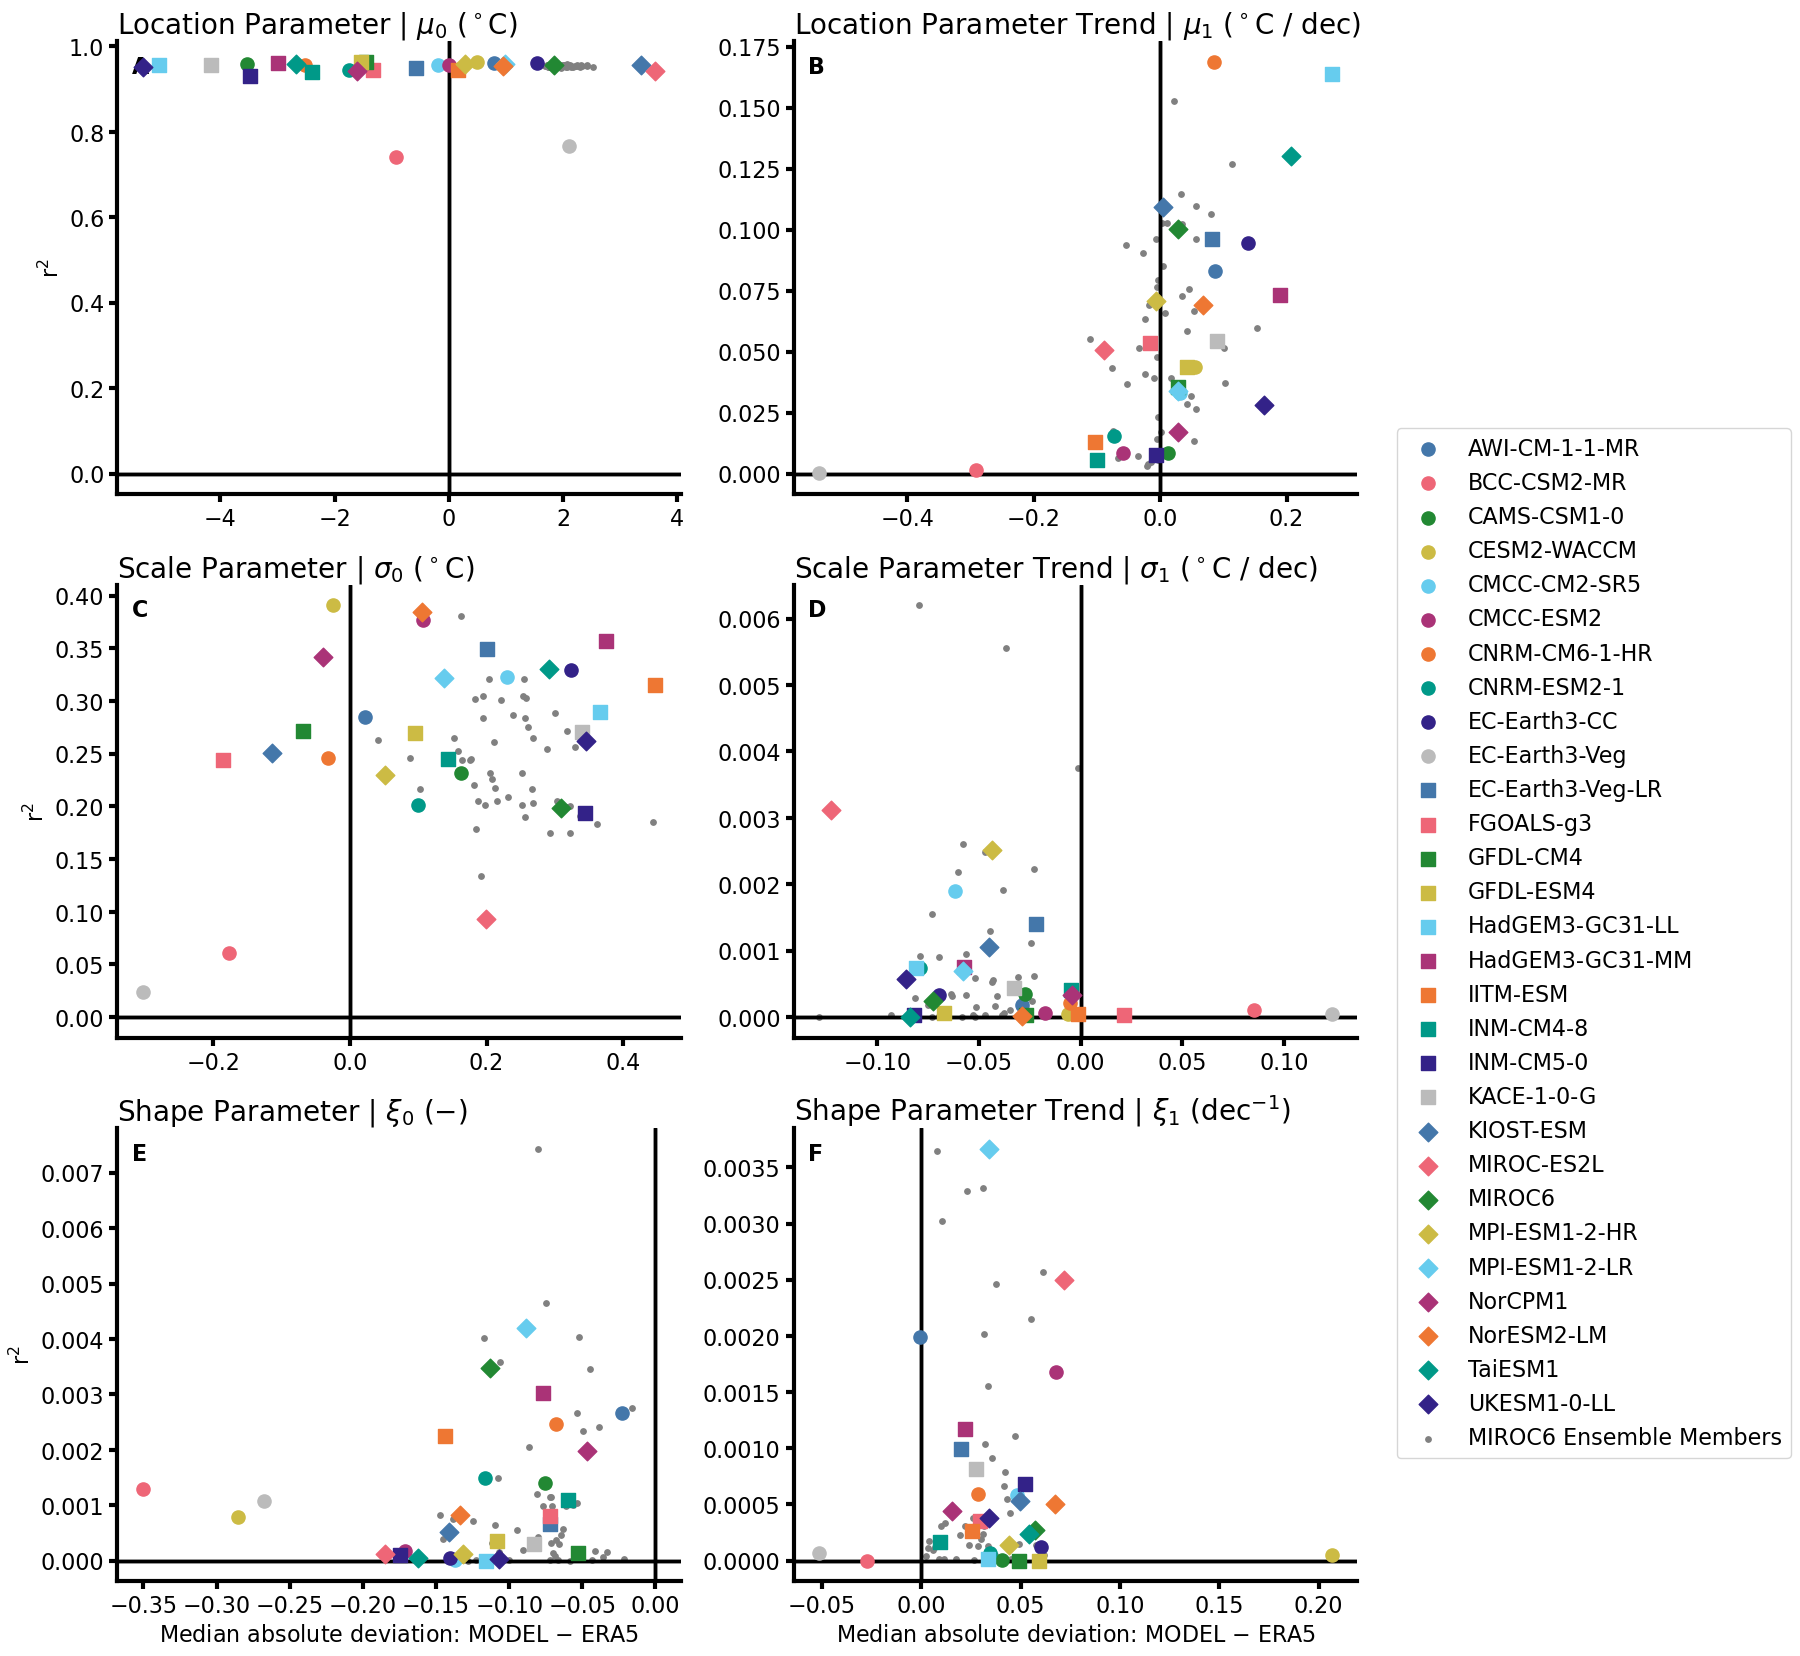

In [41]:
fig, ax = plt.subplots(3, 2, figsize=(16, 20))
titles = [r'Location Parameter | $\mu_0$ $(^\circ$C$)$', r"Location Parameter Trend | $\mu_1$ $(^\circ$C / dec$)$",
        r'Scale Parameter | $\sigma_0$ $(^\circ$C$)$', r"Scale Parameter Trend | $\sigma_1$ $(^\circ$C / dec$)$",
        r'Shape Parameter | $\xi_0$ $(-)$', r"Shape Parameter Trend | $\xi_1$ $($dec$^{-1})$"]
models = list(CMIPConfig.iter_active_models(cmip_variable))

have_ylabels = [0, 2, 4]
have_xlabels = [4, 5]

for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s_prim.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in enumerate(models):
        if m.name == model_with_most:
            most_color = colors[mdx % 10]

        marker = markers[mdx // 10]  # choose marker
        color = colors[mdx % 10]  # choose color

        a.scatter(med_abs_dev_prim[var][mdx], r2s_prim[var][mdx], s=90, marker=marker, color=color, label=m.name, zorder=100)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("$r^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Median absolute deviation: MODEL $-$ ERA5")


for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s_most.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in zip(range(N_members), ds.member_id.values):
        a.scatter(med_abs_dev_most[var][mdx], r2s_most[var][mdx], s=60, marker='.', color='grey', zorder=1,
                  label=f'{model_with_most} Ensemble Members' if mdx == 0 else None)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("r$^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Median absolute deviation: MODEL $-$ ERA5")

ax[1,1].legend(bbox_to_anchor=(1.05, 1.37), frameon=True)

labels = ['A', 'B', 'C', 'D', 'E', 'F']
for a, label in zip(ax.flatten(), labels):
    a.text(0.025, 0.97, label, transform=a.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

if save_figs:
    fname = make_figure_filename(f'all_cmip_era5_r2_medbias_{cmip_variable}_{anom_type}_{fit}', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

## Additional analysis (quoted numbers, etc.)

In [112]:
merged_dict = {var: np.hstack([r2s_prim[var], r2s_most[var]]) for var in r2s_prim.keys()}

In [113]:
# make data frames of primary members only and primary + all the MIROC members 
df_prim = pd.DataFrame(r2s_prim, index=[m.name for m in models])
df_merged = pd.DataFrame(merged_dict, index=[m.name for m in models] + [f'{model_with_most}_member_{i}' for i in range(N_members)])

# take means
prim_means = df_prim.mean()
merged_means = df_merged.mean()

prim_meds = df_prim.median()
merged_meds = df_merged.median()

prim_maxs = df_prim.max()
merged_maxs = df_merged.max()

In [114]:
print("*" * len("*" * 50 + f" SUMMARY STATISTICS FOR {anom_type} FITS " + "*" * 50))
print("*" * 50 + f" SUMMARY STATISTICS FOR {anom_type} FITS " + "*" * 50)
print("*" * len("*" * 50 + f" SUMMARY STATISTICS FOR {anom_type} FITS " + "*" * 50))
print("\n")

print("=" * 50 + " PRIMARY MEMBERS " + "=" * 50)
print("-" * 50 + " AVERAGES " + "-" * 50)
print(f"The average stationary location parameter r-squared value is {prim_means['loc']}")
print(f"The average trend location parameter r-squared value is {prim_means['loc_trend']}")
print(f"The average stationary scale parameter r-squared value is {prim_means['scale']}")
print(f"The average trend scale parameter r-squared value is {prim_means['scale_trend']}")
print(f"The average stationary shape parameter r-squared value is {prim_means['shape']}")
print(f"The average trend shape parameter r-squared value is {prim_means['shape_trend']}")

print("-" * 50 + " MEDIANS " + "-" * 50)
print(f"The median stationary location parameter r-squared value is {prim_meds['loc']}")
print(f"The median trend location parameter r-squared value is {prim_meds['loc_trend']}")
print(f"The median stationary scale parameter r-squared value is {prim_meds['scale']}")
print(f"The median trend scale parameter r-squared value is {prim_meds['scale_trend']}")
print(f"The median stationary shape parameter r-squared value is {prim_meds['shape']}")
print(f"The median trend shape parameter r-squared value is {prim_meds['shape_trend']}")

print("-" * 50 + " MAXIMA " + "-" * 50)
print(f"The maximum stationary location parameter r-squared value is {prim_maxs['loc']}")
print(f"The maximum trend location parameter r-squared value is {prim_maxs['loc_trend']}")
print(f"The maximum stationary scale parameter r-squared value is {prim_maxs['scale']}")
print(f"The maximum trend scale parameter r-squared value is {prim_maxs['scale_trend']}")
print(f"The maximum stationary shape parameter r-squared value is {prim_maxs['shape']}")
print(f"The maximum trend shape parameter r-squared value is {prim_maxs['shape_trend']}")

print("\n")
print("=" * 50 + " PRIMARY + ALL MIROC MEMBERS " + "=" * 50)
print("-" * 50 + " AVERAGES " + "-" * 50)
print(f"The average stationary location parameter r-squared value is {merged_means['loc']}")
print(f"The average trend location parameter r-squared value is {merged_means['loc_trend']}")
print(f"The average stationary scale parameter r-squared value is {merged_means['scale']}")
print(f"The average trend scale parameter r-squared value is {merged_means['scale_trend']}")
print(f"The average stationary shape parameter r-squared value is {merged_means['shape']}")
print(f"The average trend shape parameter r-squared value is {merged_means['shape_trend']}")

print("-" * 50 + " MEDIANS " + "-" * 50)
print(f"The median stationary location parameter r-squared value is {merged_meds['loc']}")
print(f"The median trend location parameter r-squared value is {merged_meds['loc_trend']}")
print(f"The median stationary scale parameter r-squared value is {merged_meds['scale']}")
print(f"The median trend scale parameter r-squared value is {merged_meds['scale_trend']}")
print(f"The median stationary shape parameter r-squared value is {merged_meds['shape']}")
print(f"The median trend shape parameter r-squared value is {merged_meds['shape_trend']}")

print("-" * 50 + " MAXIMA " + "-" * 50)
print(f"The maximum stationary location parameter r-squared value is {merged_maxs['loc']}")
print(f"The maximum trend location parameter r-squared value is {merged_maxs['loc_trend']}")
print(f"The maximum stationary scale parameter r-squared value is {merged_maxs['scale']}")
print(f"The maximum trend scale parameter r-squared value is {merged_maxs['scale_trend']}")
print(f"The maximum stationary shape parameter r-squared value is {merged_maxs['shape']}")
print(f"The maximum trend shape parameter r-squared value is {merged_maxs['shape_trend']}")

*****************************************************************************************************************************************
************************************************** SUMMARY STATISTICS FOR annmean FITS **************************************************
*****************************************************************************************************************************************


================================================== PRIMARY MEMBERS ==================================================
-------------------------------------------------- AVERAGES --------------------------------------------------
The average stationary location parameter r-squared value is 0.7945982640470223
The average trend location parameter r-squared value is 0.01757550353251227
The average stationary scale parameter r-squared value is 0.18099929779718146
The average trend scale parameter r-squared value is 0.0032985635948485767
The average stationary shape parameter r-squar